[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bluerrror/germany-hydrology/blob/main/examples/quickstart.ipynb)

# German hydrology data — quickstart

One catchment, everything a rainfall–runoff model needs, fetched with
`earthkit.data.from_source(...)`:

1. **catchments & rivers** (HydroSHEDS) around the Weser headwaters,
2. **river gauges** with live water levels (PEGELONLINE),
3. **observed climate** at a DWD station vs **ERA5 reanalysis** at the same spot,
4. the **soil map** underneath (BGR BÜK1000).

All sources are free and keyless.

In [1]:
# Setup — no-op locally; on Colab installs the plugin from GitHub
import importlib.util

if importlib.util.find_spec("germany_hydrology") is None:
    %pip install -q git+https://github.com/Bluerrror/germany-hydrology

In [2]:
import earthkit.data as ekd
import matplotlib.pyplot as plt

ekd.config.set("cache-policy", "user")   # keep downloads between sessions

BBOX = [9.0, 51.0, 10.6, 52.0]           # Weser headwaters (Fulda/Werra junction)

## 1. Catchments, rivers and gauges on one map

HydroBASINS gives nested Pfafstetter catchments (level 7 ≈ mesoscale),
HydroRIVERS the river network, and PEGELONLINE every federal waterway gauge
with coordinates.

In [3]:
basins = ekd.from_source("hydrosheds", product="basins", level=7, bbox=BBOX).to_pandas()
rivers = ekd.from_source("hydrosheds", product="rivers", bbox=BBOX).to_pandas()
gauges = ekd.from_source("pegelonline").to_pandas()
gauges = gauges[gauges["longitude"].between(BBOX[0], BBOX[2])
                & gauges["latitude"].between(BBOX[1], BBOX[3])]

print(f"{len(basins)} catchments, {len(rivers)} river segments, {len(gauges)} gauges")
gauges[["water", "longitude", "latitude", "timeseries"]].head(8)

8 catchments, 684 river segments, 14 gauges


,water,longitude,latitude,timeseries
shortname,,,,
AFFOLDERN,EDER,9.084726,51.164141,W
EDERTALSPERRE,EDER,9.058928,51.184040,W
BONAFORTH,FULDA,9.632042,51.403492,"Q,W"
GUNTERSHAUSEN,FULDA,9.469333,51.226580,"Q,W"
GREBENAU,FULDA,9.498194,51.193131,"Q,W"
ROTENBURG,FULDA,9.720450,51.003768,"Q,W"
LETZTER HELLER,WERRA,9.678081,51.415651,"Q,W"
ALLENDORF,WERRA,9.966471,51.276767,"W,WT"


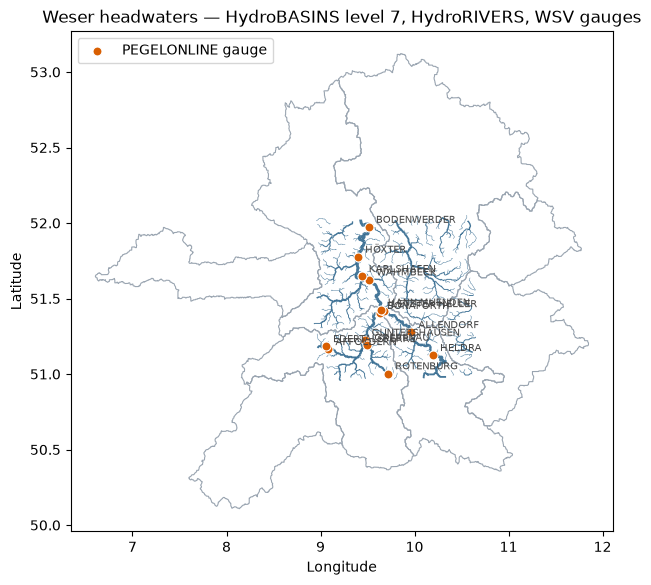

In [4]:
fig, ax = plt.subplots(figsize=(8, 6.5))
basins.boundary.plot(ax=ax, color="#9aa5b1", lw=0.8)
rivers.plot(ax=ax, color="#31688e", lw=rivers["ORD_STRA"] / 3, alpha=0.9)
ax.scatter(gauges["longitude"], gauges["latitude"], s=42, color="#d95f02",
           edgecolor="white", lw=0.8, zorder=3, label="PEGELONLINE gauge")
for name, g in gauges.iterrows():
    ax.annotate(name, (g["longitude"], g["latitude"]), fontsize=7,
                textcoords="offset points", xytext=(5, 3), color="#444444")
ax.set_title("Weser headwaters — HydroBASINS level 7, HydroRIVERS, WSV gauges")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="upper left")
import os
if os.path.isdir("../docs"):  # keep the README preview image up to date
    fig.savefig("../docs/weser_map.png", dpi=110, bbox_inches="tight")
plt.show()

## 2. Live water level at a gauge

PEGELONLINE serves raw 15-minute values for the last ~31 days.

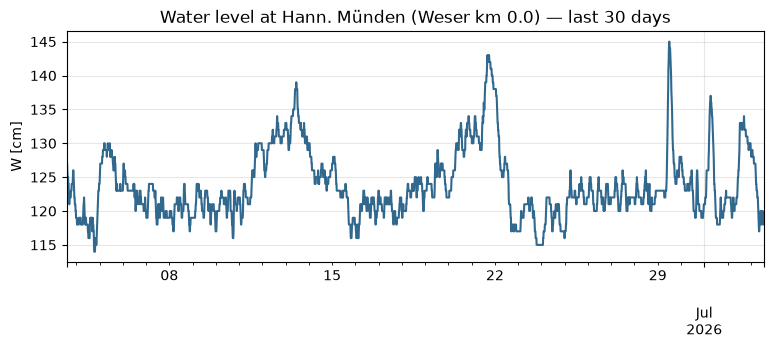

In [5]:
level = ekd.from_source("pegelonline", station="HANN.MUENDEN",
                        parameter="W", start="P30D").to_pandas()

fig, ax = plt.subplots(figsize=(9, 3))
level.iloc[:, 0].plot(ax=ax, color="#31688e", lw=1.5)
ax.set_title("Water level at Hann. Münden (Weser km 0.0) — last 30 days")
ax.set_ylabel(level.columns[0]); ax.set_xlabel("")
ax.grid(alpha=0.3)
plt.show()

## 3. Observed climate (DWD) vs reanalysis (ERA5)

The DWD station catalogue tells us what exists; then we pull one station's
full daily record and ERA5 at the same coordinates, and compare monthly
precipitation. DWD columns: `RSK` = precipitation (mm), `TMK` = mean
temperature (°C).

In [6]:
stations = ekd.from_source("dwd-observations").to_pandas()
goe = stations[stations["name"].str.contains("Göttingen")]
goe

,from_date,to_date,elevation,latitude,longitude,name,state,access
station_id,,,,,,,,
01691,1858-01-01,2026-07-02,167,51.5002,9.9507,Göttingen,Niedersachsen,Frei


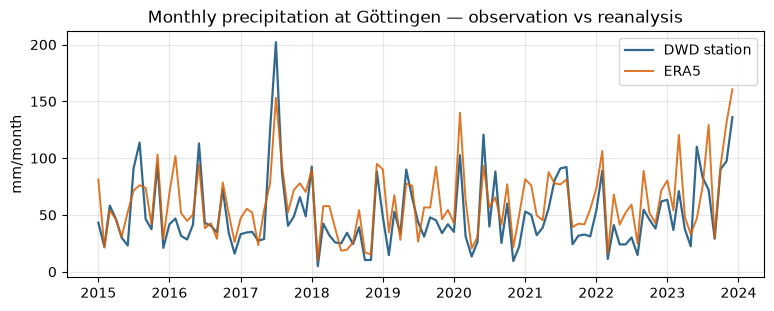

correlation (monthly sums): 0.803


In [7]:
sid = goe.index[0]
dwd = ekd.from_source("dwd-observations", station=sid, period="all").to_pandas()

era5 = ekd.from_source(
    "era5-timeseries",
    latitude=goe["latitude"].iloc[0], longitude=goe["longitude"].iloc[0],
    start="2015-01-01", end="2023-12-31",
    variables=["precipitation_sum", "temperature_2m_mean"],
).to_pandas()

monthly = {
    "DWD station": dwd["RSK"]["2015":"2023"].resample("MS").sum(),
    "ERA5": era5["precipitation_sum"].resample("MS").sum(),
}

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(monthly["DWD station"], color="#31688e", lw=1.6, label="DWD station")
ax.plot(monthly["ERA5"], color="#d95f02", lw=1.4, alpha=0.85, label="ERA5")
ax.set_title(f"Monthly precipitation at {goe['name'].iloc[0]} — observation vs reanalysis")
ax.set_ylabel("mm/month"); ax.grid(alpha=0.3); ax.legend()
plt.show()

both = monthly["DWD station"].to_frame("dwd").join(monthly["ERA5"].rename("era5")).dropna()
print("correlation (monthly sums):", round(both["dwd"].corr(both["era5"]), 3))

## 4. The soil map underneath (BÜK1000)

BGR's 1:1M soil map as polygons; `Legende` carries the soil-unit description.
Colors only distinguish units (identity, arbitrary hues).

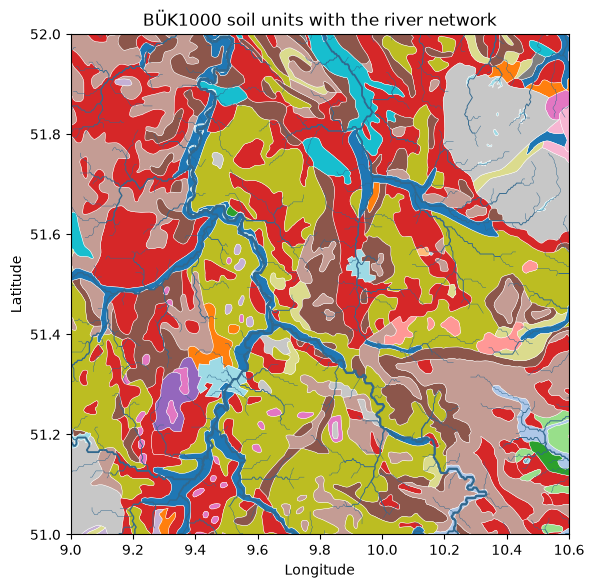

,Symbol,Legende
0,51,Pelosol-Braunerde / Pelosol-Pseudogley aus Ver...
1,42,Parabraunerde / Fahlerde / Pseudogley aus Löss...
3,53,Braunerde aus basischen und intermediären magm...
5,49,Rendzina / Braunerde-Rendzina / Pararendzina a...
11,61,Podsolige Braunerde aus basenarmen quarzitisch...
13,52,Braunerde aus Mergelgesteinen und kalkhaltigen...
15,40,Tschernosem-Parabraunerde / Parabraunerde-Tsch...
18,38,Tschernosem / Pseudogley-Tschernosem aus Löss ...


In [8]:
soils = ekd.from_source("buek1000", bbox=BBOX).to_pandas()

fig, ax = plt.subplots(figsize=(8, 6.5))
soils.plot(ax=ax, column="Symbol", cmap="tab20", edgecolor="white", lw=0.3)
rivers.plot(ax=ax, color="#31688e", lw=rivers["ORD_STRA"] / 3)
ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
ax.set_title("BÜK1000 soil units with the river network")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()

soils[["Symbol", "Legende"]].drop_duplicates().head(8)

## Where to go from here

- Parameter tables for all five sources are in the
  [README](../README.md#sources-in-detail).
- Gridded soil properties (pH, texture, SOC ...) come from the companion
  plugin [earthkit-data-soilgrids](https://github.com/Bluerrror/earthkit-data-soilgrids).
- **Attribution**: DWD (CC-BY 4.0), WSV/PEGELONLINE (raw values, GeoNutzV),
  HydroSHEDS ([Lehner & Grill 2013](https://doi.org/10.1002/hyp.9740)),
  BÜK1000 © BGR Hannover, ERA5 via Open-Meteo (CC-BY 4.0 /
  Copernicus).